<a href="https://colab.research.google.com/github/seop-byte/worldcup-2026-winner-prediction/blob/main/worldcup_2026_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026 FIFA World Cup Winner Prediction

## Project Goal
This project aims to predict the winning probability of national teams in the 2026 FIFA World Cup using player market values, historical World Cup records, and tournament simulation.

## Problem Definition
Since the final result of the 2026 World Cup is unknown, this project treats the prediction task as a simulation-based machine learning problem. Team strength is estimated using player market values and historical performance records, and match results are simulated based on relative team strength.

## Main Steps
1. Load player and historical World Cup data
2. Preprocess market values and positions
3. Calculate national team strength
4. Build baseline and improved strength models
5. Simulate the 2026 tournament format
6. Estimate winning probability through repeated simulations
7. Compare results across different models

## Expected Output
- Team strength ranking
- Match win probability
- World Cup tournament simulation results
- Predicted winning probability for each country

In [54]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [55]:
!pip install kagglehub

In [56]:
# 1. 필요한 라이브러리
import pandas as pd
import numpy as np
import os

# 2. 파일 업로드
from google.colab import files
uploaded = files.upload()

# 3. CSV 파일 읽기
matches = pd.read_csv("all_matches.csv")
countries = pd.read_csv("countries_names.csv")
players = pd.read_csv("players.csv")
valuations = pd.read_csv("player_valuations.csv")

# 4. 데이터 크기 확인
print("matches:", matches.shape)
print("countries:", countries.shape)
print("players:", players.shape)
print("valuations:", valuations.shape)

# 5. 컬럼 확인
print("\n[matches columns]")
print(matches.columns.tolist())

print("\n[countries columns]")
print(countries.columns.tolist())

print("\n[players columns]")
print(players.columns.tolist())

print("\n[valuations columns]")
print(valuations.columns.tolist())

# 6. 앞부분 확인
display(matches.head())
display(countries.head())
display(players.head())
display(valuations.head())

Saving all_matches.csv to all_matches (1).csv
Saving countries_names.csv to countries_names (1).csv
Saving player_valuations.csv to player_valuations (1).csv
Saving players.csv to players (1).csv
matches: (51492, 8)
countries: (289, 3)
players: (47669, 26)
valuations: (640176, 6)

[matches columns]
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']

[countries columns]
['original_name', 'current_name', 'color_code']

[players columns]
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

[valuations columns]
['player_id

,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


,original_name,current_name,color_code
0,Afghanistan,Afghanistan,#AF2B34
1,Albania,Albania,#E41A13
2,Algeria,Algeria,#006233
3,Andorra,Andorra,#FFB800
4,Angola,Angola,#FF0000


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


In [57]:
# 날짜 형식 변환
matches["date"] = pd.to_datetime(matches["date"])
valuations["date"] = pd.to_datetime(valuations["date"])

# 국가명 통일용 dictionary 만들기
country_map = dict(zip(countries["original_name"], countries["current_name"]))

# all_matches의 국가명 통일
matches["home_team"] = matches["home_team"].replace(country_map)
matches["away_team"] = matches["away_team"].replace(country_map)
matches["country"] = matches["country"].replace(country_map)

# players의 국적도 국가명 통일
players["country_of_citizenship"] = players["country_of_citizenship"].replace(country_map)

print("Date converted and country names normalized.")
display(matches.head())
display(players[["player_id", "name", "country_of_citizenship", "position", "sub_position"]].head())

Date converted and country names normalized.


,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


,player_id,name,country_of_citizenship,position,sub_position
0,10,Miroslav Klose,Germany,Attack,Centre-Forward
1,26,Roman Weidenfeller,Germany,Goalkeeper,Goalkeeper
2,65,Dimitar Berbatov,Bulgaria,Attack,Centre-Forward
3,77,Lúcio,Brazil,Defender,Centre-Back
4,80,Tom Starke,Germany,Goalkeeper,Goalkeeper


In [58]:
# 최근 5개 월드컵 기준 직전 기간 설정
# 각 월드컵 시작 전까지의 A매치 성적을 feature로 사용

world_cup_periods = {
    2010: ("2006-07-10", "2010-06-10"),
    2014: ("2010-07-12", "2014-06-11"),
    2018: ("2014-07-14", "2018-06-13"),
    2022: ("2018-07-16", "2022-11-19")
}

def make_team_stats(matches_df, start_date, end_date, wc_year):
    period_matches = matches_df[
        (matches_df["date"] >= start_date) &
        (matches_df["date"] <= end_date)
    ].copy()

    # 홈팀 기준
    home = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    home = home.rename(columns={
        "home_team": "team",
        "away_team": "opponent",
        "home_score": "goals_for",
        "away_score": "goals_against"
    })

    home["result"] = np.where(
        home["goals_for"] > home["goals_against"], "W",
        np.where(home["goals_for"] == home["goals_against"], "D", "L")
    )

    # 원정팀 기준
    away = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    away = away.rename(columns={
        "away_team": "team",
        "home_team": "opponent",
        "away_score": "goals_for",
        "home_score": "goals_against"
    })

    away["result"] = np.where(
        away["goals_for"] > away["goals_against"], "W",
        np.where(away["goals_for"] == away["goals_against"], "D", "L")
    )

    # 홈/원정 합치기
    team_records = pd.concat([home, away], ignore_index=True)

    # 국가별 통계 계산
    team_stats = team_records.groupby("team").agg(
        matches_played=("result", "count"),
        wins=("result", lambda x: (x == "W").sum()),
        draws=("result", lambda x: (x == "D").sum()),
        losses=("result", lambda x: (x == "L").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum")
    ).reset_index()

    team_stats["goal_difference"] = team_stats["goals_for"] - team_stats["goals_against"]
    team_stats["win_rate"] = team_stats["wins"] / team_stats["matches_played"]
    team_stats["points"] = team_stats["wins"] * 3 + team_stats["draws"]
    team_stats["points_per_match"] = team_stats["points"] / team_stats["matches_played"]
    team_stats["goals_for_per_match"] = team_stats["goals_for"] / team_stats["matches_played"]
    team_stats["goals_against_per_match"] = team_stats["goals_against"] / team_stats["matches_played"]
    team_stats["world_cup_year"] = wc_year

    return team_stats

In [59]:
# 5개 월드컵에 대해 국가별 직전 4년 성적 계산

all_team_stats = []

for wc_year, (start_date, end_date) in world_cup_periods.items():
    temp = make_team_stats(matches, start_date, end_date, wc_year)
    all_team_stats.append(temp)

all_team_stats = pd.concat(all_team_stats, ignore_index=True)

print("전체 국가-월드컵 성적 데이터 크기:", all_team_stats.shape)
display(all_team_stats.head(20))

전체 국가-월드컵 성적 데이터 크기: (1121, 14)


,team,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,win_rate,points,points_per_match,goals_for_per_match,goals_against_per_match,world_cup_year
0,Afghanistan,14,2,2,10,8,44,-36,0.142857,8,0.571429,0.571429,3.142857,2006
1,Albania,34,12,5,17,43,54,-11,0.352941,41,1.205882,1.264706,1.588235,2006
2,Algeria,43,14,15,14,49,51,-2,0.325581,57,1.325581,1.139535,1.186047,2006
3,American Samoa,4,0,0,4,1,34,-33,0.000000,0,0.000000,0.250000,8.500000,2006
4,Andorra,25,1,3,21,5,65,-60,0.040000,6,0.240000,0.200000,2.600000,2006
5,Angola,47,19,14,14,61,50,11,0.404255,71,1.510638,1.297872,1.063830,2006
6,Anguilla,4,0,1,3,1,10,-9,0.000000,1,0.250000,0.250000,2.500000,2006
7,Antigua and Barbuda,19,5,2,12,21,37,-16,0.263158,17,0.894737,1.105263,1.947368,2006
8,Argentina,50,30,10,10,94,55,39,0.600000,100,2.000000,1.880000,1.100000,2006
9,Armenia,29,6,4,19,23,55,-32,0.206897,22,0.758621,0.793103,1.896552,2006


In [60]:
# 월드컵 연도별 국가 수 확인

display(
    all_team_stats.groupby("world_cup_year")["team"]
    .nunique()
    .reset_index(name="num_teams")
)

,world_cup_year,num_teams
0,2006,225
1,2010,221
2,2014,228
3,2018,224
4,2022,223


In [61]:
# 월드컵별 시장가치 기준일
# 각 월드컵 시작 전날 또는 시작 직전 날짜를 기준으로 잡음

wc_cutoff_dates = {
    2010: "2010-06-10",
    2014: "2014-06-11",
    2018: "2018-06-13",
    2022: "2022-11-19"
}

# 선수 데이터와 시장가치 데이터 합치기
player_value_data = valuations.merge(
    players[["player_id", "name", "country_of_citizenship", "position", "sub_position"]],
    on="player_id",
    how="left"
)

# 확인
print(player_value_data.shape)
display(player_value_data.head())

(640176, 10)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id,name,country_of_citizenship,position,sub_position
0,405973,2000-01-20,150000,Unknown,3057,BE1,Fadel Gobitaka,Togo,Attack,Left Winger
1,342216,2001-07-20,100000,Unknown,1241,SC1,Julien Serrano,France,Defender,Left-Back
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1,Florin Cernat,Romania,Midfield,Attacking Midfield
3,6893,2003-12-15,900000,Galatasaray,984,GB1,Gabriel Tamas,Romania,Defender,Centre-Back
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1,Miroslav Klose,Germany,Attack,Centre-Forward


In [62]:
# 포지션을 4-3-3 기준 그룹으로 단순화하는 함수

def position_group(position):
    if position == "Goalkeeper":
        return "GK"
    elif position == "Defender":
        return "DF"
    elif position == "Midfield":
        return "MF"
    elif position == "Attack":
        return "FW"
    else:
        return "OTHER"

player_value_data["position_group"] = player_value_data["position"].apply(position_group)

display(player_value_data[["name", "country_of_citizenship", "position", "sub_position", "position_group", "market_value_in_eur", "date"]].head(20))

,name,country_of_citizenship,position,sub_position,position_group,market_value_in_eur,date
0,Fadel Gobitaka,Togo,Attack,Left Winger,FW,150000,2000-01-20
1,Julien Serrano,France,Defender,Left-Back,DF,100000,2001-07-20
2,Florin Cernat,Romania,Midfield,Attacking Midfield,MF,400000,2003-12-09
3,Gabriel Tamas,Romania,Defender,Centre-Back,DF,900000,2003-12-15
4,Miroslav Klose,Germany,Attack,Centre-Forward,FW,7000000,2004-10-04
5,Roman Weidenfeller,Germany,Goalkeeper,Goalkeeper,GK,1500000,2004-10-04
6,Dimitar Berbatov,Bulgaria,Attack,Centre-Forward,FW,8000000,2004-10-04
7,Lúcio,Brazil,Defender,Centre-Back,DF,13000000,2004-10-04
8,Tom Starke,Germany,Goalkeeper,Goalkeeper,GK,400000,2004-10-04
9,Dedê,Brazil,Defender,Left-Back,DF,9500000,2004-10-04


In [63]:
# 특정 월드컵 기준일 이전의 선수별 최신 시장가치 가져오기

def get_latest_values_before_cutoff(df, cutoff_date, wc_year):
    cutoff_date = pd.to_datetime(cutoff_date)

    temp = df[df["date"] <= cutoff_date].copy()

    # 선수별로 기준일 이전 가장 최근 시장가치만 남김
    temp = temp.sort_values(["player_id", "date"])
    latest = temp.groupby("player_id").tail(1).copy()

    latest["world_cup_year"] = wc_year

    return latest

In [64]:
# 월드컵별 국가별 4-3-3 베스트11 시장가치 합 계산

def calculate_best11_market_value(latest_values, wc_year):
    result_rows = []

    for country, group in latest_values.groupby("country_of_citizenship"):
        gk = group[group["position_group"] == "GK"].nlargest(1, "market_value_in_eur")
        df = group[group["position_group"] == "DF"].nlargest(4, "market_value_in_eur")
        mf = group[group["position_group"] == "MF"].nlargest(3, "market_value_in_eur")
        fw = group[group["position_group"] == "FW"].nlargest(3, "market_value_in_eur")

        best11 = pd.concat([gk, df, mf, fw])

        # 4-3-3을 완성할 수 있는 국가만 사용
        if len(gk) == 1 and len(df) == 4 and len(mf) == 3 and len(fw) == 3:
            result_rows.append({
                "team": country,
                "world_cup_year": wc_year,
                "best11_market_value": best11["market_value_in_eur"].sum(),
                "avg_best11_market_value": best11["market_value_in_eur"].mean(),
                "num_best11_players": len(best11),
                "gk_value": gk["market_value_in_eur"].sum(),
                "df_value": df["market_value_in_eur"].sum(),
                "mf_value": mf["market_value_in_eur"].sum(),
                "fw_value": fw["market_value_in_eur"].sum()
            })

    return pd.DataFrame(result_rows)


all_market_values = []

for wc_year, cutoff_date in wc_cutoff_dates.items():
    latest_values = get_latest_values_before_cutoff(player_value_data, cutoff_date, wc_year)
    market_df = calculate_best11_market_value(latest_values, wc_year)
    all_market_values.append(market_df)

all_market_values = pd.concat(all_market_values, ignore_index=True)

print("시장가치 데이터 크기:", all_market_values.shape)
display(all_market_values.head(20))

# 연도별 시장가치 계산 가능한 국가 수
display(
    all_market_values.groupby("world_cup_year")["team"]
    .nunique()
    .reset_index(name="num_teams_with_market_value")
)

시장가치 데이터 크기: (416, 9)


,team,world_cup_year,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,Argentina,2006,145000000,1.318182e+07,11,6500000,46000000,51000000,41500000
1,Austria,2006,23650000,2.150000e+06,11,1400000,10000000,8200000,4050000
2,Belgium,2006,63000000,5.727273e+06,11,3500000,36500000,11000000,12000000
3,Brazil,2006,171500000,1.559091e+07,11,6000000,59000000,69000000,37500000
4,Cameroon,2006,66900000,6.081818e+06,11,4000000,7600000,13500000,41800000
5,Cote d'Ivoire,2006,78250000,7.113636e+06,11,900000,18850000,18000000,40500000
6,Croatia,2006,45200000,4.109091e+06,11,2500000,10750000,10700000,21250000
7,Czech Republic,2006,72950000,6.631818e+06,11,22000000,18200000,22000000,10750000
8,Denmark,2006,57200000,5.200000e+06,11,6200000,20500000,20000000,10500000
9,England,2006,261100000,2.373636e+07,11,7850000,85250000,87000000,81000000


,world_cup_year,num_teams_with_market_value
0,2006,27
1,2010,61
2,2014,89
3,2018,109
4,2022,130


In [65]:
# 월드컵 본선 참가국 리스트
# 일단 시장가치 데이터가 상대적으로 충분한 2010, 2014, 2018, 2022 사용

world_cup_teams = {
    2010: [
        "South Africa", "Mexico", "Uruguay", "France",
        "Argentina", "Nigeria", "South Korea", "Greece",
        "England", "United States", "Algeria", "Slovenia",
        "Germany", "Australia", "Serbia", "Ghana",
        "Netherlands", "Denmark", "Japan", "Cameroon",
        "Italy", "Paraguay", "New Zealand", "Slovakia",
        "Brazil", "North Korea", "Ivory Coast", "Portugal",
        "Spain", "Switzerland", "Honduras", "Chile"
    ],
    2014: [
        "Brazil", "Croatia", "Mexico", "Cameroon",
        "Spain", "Netherlands", "Chile", "Australia",
        "Colombia", "Greece", "Ivory Coast", "Japan",
        "Uruguay", "Costa Rica", "England", "Italy",
        "Switzerland", "Ecuador", "France", "Honduras",
        "Argentina", "Bosnia-Herzegovina", "Iran", "Nigeria",
        "Germany", "Portugal", "Ghana", "United States",
        "Belgium", "Algeria", "Russia", "South Korea"
    ],
    2018: [
        "Russia", "Saudi Arabia", "Egypt", "Uruguay",
        "Portugal", "Spain", "Morocco", "Iran",
        "France", "Australia", "Peru", "Denmark",
        "Argentina", "Iceland", "Croatia", "Nigeria",
        "Brazil", "Switzerland", "Costa Rica", "Serbia",
        "Germany", "Mexico", "Sweden", "South Korea",
        "Belgium", "Panama", "Tunisia", "England",
        "Poland", "Senegal", "Colombia", "Japan"
    ],
    2022: [
        "Qatar", "Ecuador", "Senegal", "Netherlands",
        "England", "Iran", "United States", "Wales",
        "Argentina", "Saudi Arabia", "Mexico", "Poland",
        "France", "Australia", "Denmark", "Tunisia",
        "Spain", "Costa Rica", "Germany", "Japan",
        "Belgium", "Canada", "Morocco", "Croatia",
        "Brazil", "Serbia", "Switzerland", "Cameroon",
        "Portugal", "Ghana", "Uruguay", "South Korea"
    ]
}

# 참가국 리스트를 DataFrame으로 변환
wc_team_rows = []

for year, teams in world_cup_teams.items():
    for team in teams:
        wc_team_rows.append({
            "world_cup_year": year,
            "team": team
        })

wc_teams_df = pd.DataFrame(wc_team_rows)

print(wc_teams_df.shape)
display(wc_teams_df.head())

(160, 2)


,world_cup_year,team
0,2006,Germany
1,2006,Costa Rica
2,2006,Poland
3,2006,Ecuador
4,2006,England


In [66]:
# 월드컵 참가국 기준으로 경기 성적 데이터 필터링

team_stats_wc = wc_teams_df.merge(
    all_team_stats,
    on=["world_cup_year", "team"],
    how="left"
)

print("월드컵 참가국 경기 성적 데이터:", team_stats_wc.shape)
display(team_stats_wc.head(20))

# 결측치 확인
display(team_stats_wc.isnull().sum())

월드컵 참가국 경기 성적 데이터: (160, 14)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,win_rate,points,points_per_match,goals_for_per_match,goals_against_per_match
0,2006,Germany,52.0,26.0,14.0,12.0,107.0,66.0,41.0,0.500000,92.0,1.769231,2.057692,1.269231
1,2006,Costa Rica,61.0,26.0,11.0,24.0,89.0,82.0,7.0,0.426230,89.0,1.459016,1.459016,1.344262
2,2006,Poland,53.0,32.0,7.0,14.0,102.0,54.0,48.0,0.603774,103.0,1.943396,1.924528,1.018868
3,2006,Ecuador,50.0,17.0,12.0,21.0,57.0,69.0,-12.0,0.340000,63.0,1.260000,1.140000,1.380000
4,2006,England,42.0,27.0,8.0,7.0,83.0,42.0,41.0,0.642857,89.0,2.119048,1.976190,1.000000
5,2006,Paraguay,46.0,18.0,16.0,12.0,52.0,48.0,4.0,0.391304,70.0,1.521739,1.130435,1.043478
6,2006,Trinidad and Tobago,76.0,33.0,11.0,32.0,102.0,98.0,4.0,0.434211,110.0,1.447368,1.342105,1.289474
7,2006,Sweden,52.0,22.0,18.0,12.0,103.0,52.0,51.0,0.423077,84.0,1.615385,1.980769,1.000000
8,2006,Argentina,50.0,30.0,10.0,10.0,94.0,55.0,39.0,0.600000,100.0,2.000000,1.880000,1.100000
9,2006,Ivory Coast,36.0,20.0,8.0,8.0,62.0,34.0,28.0,0.555556,68.0,1.888889,1.722222,0.944444


,0
world_cup_year,0
team,0
matches_played,3
wins,3
draws,3
losses,3
goals_for,3
goals_against,3
goal_difference,3
win_rate,3


In [67]:
# 상대 수준을 반영한 국가별 성적 계산 함수로 다시 정의

def make_team_stats(matches_df, start_date, end_date, wc_year):
    period_matches = matches_df[
        (matches_df["date"] >= start_date) &
        (matches_df["date"] <= end_date)
    ].copy()

    # 홈팀 기준
    home = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    home = home.rename(columns={
        "home_team": "team",
        "away_team": "opponent",
        "home_score": "goals_for",
        "away_score": "goals_against"
    })

    home["result"] = np.where(
        home["goals_for"] > home["goals_against"], "W",
        np.where(home["goals_for"] == home["goals_against"], "D", "L")
    )

    # 원정팀 기준
    away = period_matches[[
        "date", "home_team", "away_team", "home_score", "away_score", "tournament"
    ]].copy()

    away = away.rename(columns={
        "away_team": "team",
        "home_team": "opponent",
        "away_score": "goals_for",
        "home_score": "goals_against"
    })

    away["result"] = np.where(
        away["goals_for"] > away["goals_against"], "W",
        np.where(away["goals_for"] == away["goals_against"], "D", "L")
    )

    # 홈/원정 합치기
    team_records = pd.concat([home, away], ignore_index=True)

    # 기본 승점
    team_records["result_points"] = np.where(
        team_records["result"] == "W", 3,
        np.where(team_records["result"] == "D", 1, 0)
    )

    # 먼저 각 팀의 기본 성적 계산
    basic_stats = team_records.groupby("team").agg(
        matches_played=("result", "count"),
        wins=("result", lambda x: (x == "W").sum()),
        draws=("result", lambda x: (x == "D").sum()),
        losses=("result", lambda x: (x == "L").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        points=("result_points", "sum")
    ).reset_index()

    basic_stats["goal_difference"] = basic_stats["goals_for"] - basic_stats["goals_against"]
    basic_stats["win_rate"] = basic_stats["wins"] / basic_stats["matches_played"]
    basic_stats["points_per_match"] = basic_stats["points"] / basic_stats["matches_played"]

    # 상대 강도 계산: 해당 기간의 경기당 승점을 0~1 사이로 정규화
    min_ppm = basic_stats["points_per_match"].min()
    max_ppm = basic_stats["points_per_match"].max()

    basic_stats["team_strength"] = (
        (basic_stats["points_per_match"] - min_ppm) /
        (max_ppm - min_ppm)
    )

    # 각 경기별 상대 팀 강도 붙이기
    strength_map = basic_stats.set_index("team")["team_strength"].to_dict()
    team_records["opponent_strength"] = team_records["opponent"].map(strength_map)

    # 혹시 매칭 안 되는 상대는 평균값으로 대체
    team_records["opponent_strength"] = team_records["opponent_strength"].fillna(
        team_records["opponent_strength"].mean()
    )

    # 상대 강도 보정 계수
    # 약팀 상대: 0.5배 근처
    # 중간 팀 상대: 1.25배 근처
    # 강팀 상대: 최대 2.0배
    team_records["strength_multiplier"] = 0.5 + 1.5 * team_records["opponent_strength"]

    # 보정 승점
    team_records["weighted_points"] = (
        team_records["result_points"] * team_records["strength_multiplier"]
    )

    # 최종 팀 통계
    team_stats = team_records.groupby("team").agg(
        matches_played=("result", "count"),
        wins=("result", lambda x: (x == "W").sum()),
        draws=("result", lambda x: (x == "D").sum()),
        losses=("result", lambda x: (x == "L").sum()),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        points=("result_points", "sum"),
        avg_opponent_strength=("opponent_strength", "mean"),
        weighted_points=("weighted_points", "sum")
    ).reset_index()

    team_stats["goal_difference"] = team_stats["goals_for"] - team_stats["goals_against"]
    team_stats["win_rate"] = team_stats["wins"] / team_stats["matches_played"]
    team_stats["points_per_match"] = team_stats["points"] / team_stats["matches_played"]
    team_stats["weighted_points_per_match"] = team_stats["weighted_points"] / team_stats["matches_played"]
    team_stats["goals_for_per_match"] = team_stats["goals_for"] / team_stats["matches_played"]
    team_stats["goals_against_per_match"] = team_stats["goals_against"] / team_stats["matches_played"]
    team_stats["world_cup_year"] = wc_year

    return team_stats

print("보정승점 포함 make_team_stats 함수 정의 완료")

보정승점 포함 make_team_stats 함수 정의 완료


In [68]:
# 보정승점이 들어간 all_team_stats 다시 생성

all_team_stats = []

for wc_year, (start_date, end_date) in world_cup_periods.items():
    temp = make_team_stats(matches, start_date, end_date, wc_year)
    all_team_stats.append(temp)

all_team_stats = pd.concat(all_team_stats, ignore_index=True)

print("전체 국가-월드컵 성적 데이터 크기:", all_team_stats.shape)
display(all_team_stats.head(20))

display(
    all_team_stats.groupby("world_cup_year")["team"]
    .nunique()
    .reset_index(name="num_teams")
)

전체 국가-월드컵 성적 데이터 크기: (1121, 17)


,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,weighted_points,goal_difference,win_rate,points_per_match,weighted_points_per_match,goals_for_per_match,goals_against_per_match,world_cup_year
0,Afghanistan,14,2,2,10,8,44,8,0.423855,8.853936,-36,0.142857,0.571429,0.632424,0.571429,3.142857,2006
1,Albania,34,12,5,17,43,54,41,0.510788,45.524517,-11,0.352941,1.205882,1.338956,1.264706,1.588235,2006
2,Algeria,43,14,15,14,49,51,57,0.528632,66.788481,-2,0.325581,1.325581,1.553220,1.139535,1.186047,2006
3,American Samoa,4,0,0,4,1,34,0,0.496295,0.000000,-33,0.000000,0.000000,0.000000,0.250000,8.500000,2006
4,Andorra,25,1,3,21,5,65,6,0.603247,7.313241,-60,0.040000,0.240000,0.292530,0.200000,2.600000,2006
5,Angola,47,19,14,14,61,50,71,0.536111,86.357449,11,0.404255,1.510638,1.837393,1.297872,1.063830,2006
6,Anguilla,4,0,1,3,1,10,1,0.435897,1.076923,-9,0.000000,0.250000,0.269231,0.250000,2.500000,2006
7,Antigua and Barbuda,19,5,2,12,21,37,17,0.539411,20.197368,-16,0.263158,0.894737,1.063019,1.105263,1.947368,2006
8,Argentina,50,30,10,10,94,55,100,0.600089,136.290147,39,0.600000,2.000000,2.725803,1.880000,1.100000,2006
9,Armenia,29,6,4,19,23,55,22,0.559688,21.579200,-32,0.206897,0.758621,0.744110,0.793103,1.896552,2006


,world_cup_year,num_teams
0,2006,225
1,2010,221
2,2014,228
3,2018,224
4,2022,223


In [69]:
# 월드컵 참가국 기준으로 경기 성적 데이터 다시 필터링

team_stats_wc = wc_teams_df.merge(
    all_team_stats,
    on=["world_cup_year", "team"],
    how="left"
)

print("월드컵 참가국 경기 성적 데이터:", team_stats_wc.shape)
display(team_stats_wc.head(20))

# 결측치 확인
display(team_stats_wc.isnull().sum())

월드컵 참가국 경기 성적 데이터: (160, 17)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,weighted_points,goal_difference,win_rate,points_per_match,weighted_points_per_match,goals_for_per_match,goals_against_per_match
0,2006,Germany,52.0,26.0,14.0,12.0,107.0,66.0,92.0,0.593175,119.100319,41.0,0.500000,1.769231,2.290391,2.057692,1.269231
1,2006,Costa Rica,61.0,26.0,11.0,24.0,89.0,82.0,89.0,0.563991,111.538539,7.0,0.426230,1.459016,1.828501,1.459016,1.344262
2,2006,Poland,53.0,32.0,7.0,14.0,102.0,54.0,103.0,0.515050,119.064268,48.0,0.603774,1.943396,2.246496,1.924528,1.018868
3,2006,Ecuador,50.0,17.0,12.0,21.0,57.0,69.0,63.0,0.571524,79.373592,-12.0,0.340000,1.260000,1.587472,1.140000,1.380000
4,2006,England,42.0,27.0,8.0,7.0,83.0,42.0,89.0,0.584142,116.230957,41.0,0.642857,2.119048,2.767404,1.976190,1.000000
5,2006,Paraguay,46.0,18.0,16.0,12.0,52.0,48.0,70.0,0.577435,91.889170,4.0,0.391304,1.521739,1.997591,1.130435,1.043478
6,2006,Trinidad and Tobago,76.0,33.0,11.0,32.0,102.0,98.0,110.0,0.522109,133.781010,4.0,0.434211,1.447368,1.760276,1.342105,1.289474
7,2006,Sweden,52.0,22.0,18.0,12.0,103.0,52.0,84.0,0.594494,109.716966,51.0,0.423077,1.615385,2.109942,1.980769,1.000000
8,2006,Argentina,50.0,30.0,10.0,10.0,94.0,55.0,100.0,0.600089,136.290147,39.0,0.600000,2.000000,2.725803,1.880000,1.100000
9,2006,Ivory Coast,36.0,20.0,8.0,8.0,62.0,34.0,68.0,0.610305,92.542070,28.0,0.555556,1.888889,2.570613,1.722222,0.944444


,0
world_cup_year,0
team,0
matches_played,3
wins,3
draws,3
losses,3
goals_for,3
goals_against,3
points,3
avg_opponent_strength,3


In [70]:
# 월드컵 참가국 기준으로 시장가치 데이터 다시 붙이기

final_base = team_stats_wc.merge(
    all_market_values,
    on=["world_cup_year", "team"],
    how="left"
)

print("성적 + 시장가치 데이터:", final_base.shape)
display(final_base.head(20))

# 결측치 확인
display(final_base.isnull().sum())

성적 + 시장가치 데이터: (160, 24)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2006,Germany,52.0,26.0,14.0,12.0,107.0,66.0,92.0,0.593175,...,2.290391,2.057692,1.269231,91000000.0,8.272727e+06,11.0,7500000.0,25000000.0,20500000.0,38000000.0
1,2006,Costa Rica,61.0,26.0,11.0,24.0,89.0,82.0,89.0,0.563991,...,1.828501,1.459016,1.344262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,Poland,53.0,32.0,7.0,14.0,102.0,54.0,103.0,0.515050,...,2.246496,1.924528,1.018868,20125000.0,1.829545e+06,11.0,4500000.0,5150000.0,8450000.0,2025000.0
3,2006,Ecuador,50.0,17.0,12.0,21.0,57.0,69.0,63.0,0.571524,...,1.587472,1.140000,1.380000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,England,42.0,27.0,8.0,7.0,83.0,42.0,89.0,0.584142,...,2.767404,1.976190,1.000000,261100000.0,2.373636e+07,11.0,7850000.0,85250000.0,87000000.0,81000000.0
5,2006,Paraguay,46.0,18.0,16.0,12.0,52.0,48.0,70.0,0.577435,...,1.997591,1.130435,1.043478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2006,Trinidad and Tobago,76.0,33.0,11.0,32.0,102.0,98.0,110.0,0.522109,...,1.760276,1.342105,1.289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2006,Sweden,52.0,22.0,18.0,12.0,103.0,52.0,84.0,0.594494,...,2.109942,1.980769,1.000000,59450000.0,5.404545e+06,11.0,4000000.0,11200000.0,11250000.0,33000000.0
8,2006,Argentina,50.0,30.0,10.0,10.0,94.0,55.0,100.0,0.600089,...,2.725803,1.880000,1.100000,145000000.0,1.318182e+07,11.0,6500000.0,46000000.0,51000000.0,41500000.0
9,2006,Ivory Coast,36.0,20.0,8.0,8.0,62.0,34.0,68.0,0.610305,...,2.570613,1.722222,0.944444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0
world_cup_year,0
team,0
matches_played,3
wins,3
draws,3
losses,3
goals_for,3
goals_against,3
points,3
avg_opponent_strength,3


In [71]:
# 최종 feature 후보 컬럼 확인

print(final_base.columns.tolist())

display(final_base[[
    "world_cup_year",
    "team",
    "matches_played",
    "wins",
    "draws",
    "losses",
    "points_per_match",
    "avg_opponent_strength",
    "weighted_points_per_match",
    "best11_market_value"
]].head(20))

['world_cup_year', 'team', 'matches_played', 'wins', 'draws', 'losses', 'goals_for', 'goals_against', 'points', 'avg_opponent_strength', 'weighted_points', 'goal_difference', 'win_rate', 'points_per_match', 'weighted_points_per_match', 'goals_for_per_match', 'goals_against_per_match', 'best11_market_value', 'avg_best11_market_value', 'num_best11_players', 'gk_value', 'df_value', 'mf_value', 'fw_value']


,world_cup_year,team,matches_played,wins,draws,losses,points_per_match,avg_opponent_strength,weighted_points_per_match,best11_market_value
0,2006,Germany,52.0,26.0,14.0,12.0,1.769231,0.593175,2.290391,91000000.0
1,2006,Costa Rica,61.0,26.0,11.0,24.0,1.459016,0.563991,1.828501,NaN
2,2006,Poland,53.0,32.0,7.0,14.0,1.943396,0.515050,2.246496,20125000.0
3,2006,Ecuador,50.0,17.0,12.0,21.0,1.260000,0.571524,1.587472,NaN
4,2006,England,42.0,27.0,8.0,7.0,2.119048,0.584142,2.767404,261100000.0
5,2006,Paraguay,46.0,18.0,16.0,12.0,1.521739,0.577435,1.997591,NaN
6,2006,Trinidad and Tobago,76.0,33.0,11.0,32.0,1.447368,0.522109,1.760276,NaN
7,2006,Sweden,52.0,22.0,18.0,12.0,1.615385,0.594494,2.109942,59450000.0
8,2006,Argentina,50.0,30.0,10.0,10.0,2.000000,0.600089,2.725803,145000000.0
9,2006,Ivory Coast,36.0,20.0,8.0,8.0,1.888889,0.610305,2.570613,NaN


In [72]:
# 월드컵 실제 성적 label 만들기
# stage_score는 숫자가 클수록 좋은 성적
# 0: 조별리그 탈락
# 1: 16강
# 2: 8강
# 3: 4강
# 4: 준우승
# 5: 우승

world_cup_results = {
    2010: {
        "champion": ["Spain"],
        "runner_up": ["Netherlands"],
        "semi_final": ["Germany", "Uruguay"],
        "quarter_final": ["Argentina", "Brazil", "Ghana", "Paraguay"],
        "round_of_16": ["South Korea", "United States", "England", "Mexico",
                        "Slovakia", "Chile", "Portugal", "Japan"]
    },
    2014: {
        "champion": ["Germany"],
        "runner_up": ["Argentina"],
        "semi_final": ["Brazil", "Netherlands"],
        "quarter_final": ["Belgium", "Colombia", "Costa Rica", "France"],
        "round_of_16": ["Chile", "Uruguay", "Nigeria", "Algeria",
                        "Switzerland", "United States", "Mexico", "Greece"]
    },
    2018: {
        "champion": ["France"],
        "runner_up": ["Croatia"],
        "semi_final": ["Belgium", "England"],
        "quarter_final": ["Uruguay", "Brazil", "Sweden", "Russia"],
        "round_of_16": ["Argentina", "Portugal", "Spain", "Denmark",
                        "Mexico", "Japan", "Switzerland", "Colombia"]
    },
    2022: {
        "champion": ["Argentina"],
        "runner_up": ["France"],
        "semi_final": ["Croatia", "Morocco"],
        "quarter_final": ["Netherlands", "Brazil", "England", "Portugal"],
        "round_of_16": ["United States", "Australia", "Poland", "Senegal",
                        "Japan", "South Korea", "Spain", "Switzerland"]
    }
}

def get_stage_score(year, team):
    result = world_cup_results.get(year, {})

    if team in result.get("champion", []):
        return 5
    elif team in result.get("runner_up", []):
        return 4
    elif team in result.get("semi_final", []):
        return 3
    elif team in result.get("quarter_final", []):
        return 2
    elif team in result.get("round_of_16", []):
        return 1
    else:
        return 0

def get_stage_name(score):
    if score == 5:
        return "Champion"
    elif score == 4:
        return "Runner-up"
    elif score == 3:
        return "Semi-final"
    elif score == 2:
        return "Quarter-final"
    elif score == 1:
        return "Round of 16"
    else:
        return "Group stage"

final_base["stage_score"] = final_base.apply(
    lambda row: get_stage_score(row["world_cup_year"], row["team"]),
    axis=1
)

final_base["stage_name"] = final_base["stage_score"].apply(get_stage_name)

display(final_base[[
    "world_cup_year", "team", "stage_name", "stage_score",
    "points_per_match", "weighted_points_per_match",
    "best11_market_value"
]].head(40))

display(final_base["stage_name"].value_counts())

,world_cup_year,team,stage_name,stage_score,points_per_match,weighted_points_per_match,best11_market_value
0,2006,Germany,Semi-final,3,1.769231,2.290391,91000000.0
1,2006,Costa Rica,Group stage,0,1.459016,1.828501,NaN
2,2006,Poland,Group stage,0,1.943396,2.246496,20125000.0
3,2006,Ecuador,Round of 16,1,1.260000,1.587472,NaN
4,2006,England,Quarter-final,2,2.119048,2.767404,261100000.0
5,2006,Paraguay,Group stage,0,1.521739,1.997591,NaN
6,2006,Trinidad and Tobago,Group stage,0,1.447368,1.760276,NaN
7,2006,Sweden,Round of 16,1,1.615385,2.109942,59450000.0
8,2006,Argentina,Quarter-final,2,2.000000,2.725803,145000000.0
9,2006,Ivory Coast,Group stage,0,1.888889,2.570613,NaN


,count
stage_name,
Group stage,80
Round of 16,40
Quarter-final,20
Semi-final,10
Champion,5
Runner-up,5


In [73]:
# 결측치 제거해서 최종 ML 데이터셋 만들기

ml_data = final_base.dropna().copy()

print("결측치 제거 전:", final_base.shape)
print("결측치 제거 후:", ml_data.shape)

display(ml_data.head())

# 최종 데이터 저장
ml_data.to_csv("worldcup_ml_dataset.csv", index=False)

print("worldcup_ml_dataset.csv 저장 완료")

결측치 제거 전: (160, 26)
결측치 제거 후: (127, 26)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value,stage_score,stage_name
0,2006,Germany,52.0,26.0,14.0,12.0,107.0,66.0,92.0,0.593175,...,1.269231,91000000.0,8.272727e+06,11.0,7500000.0,25000000.0,20500000.0,38000000.0,3,Semi-final
2,2006,Poland,53.0,32.0,7.0,14.0,102.0,54.0,103.0,0.515050,...,1.018868,20125000.0,1.829545e+06,11.0,4500000.0,5150000.0,8450000.0,2025000.0,0,Group stage
4,2006,England,42.0,27.0,8.0,7.0,83.0,42.0,89.0,0.584142,...,1.000000,261100000.0,2.373636e+07,11.0,7850000.0,85250000.0,87000000.0,81000000.0,2,Quarter-final
7,2006,Sweden,52.0,22.0,18.0,12.0,103.0,52.0,84.0,0.594494,...,1.000000,59450000.0,5.404545e+06,11.0,4000000.0,11200000.0,11250000.0,33000000.0,1,Round of 16
8,2006,Argentina,50.0,30.0,10.0,10.0,94.0,55.0,100.0,0.600089,...,1.100000,145000000.0,1.318182e+07,11.0,6500000.0,46000000.0,51000000.0,41500000.0,2,Quarter-final


worldcup_ml_dataset.csv 저장 완료


In [74]:
# 사용할 feature와 label 설정

feature_cols = [
    "matches_played",
    "wins",
    "draws",
    "losses",
    "goals_for",
    "goals_against",
    "goal_difference",
    "win_rate",
    "points",
    "points_per_match",
    "avg_opponent_strength",
    "weighted_points",
    "weighted_points_per_match",
    "goals_for_per_match",
    "goals_against_per_match",
    "best11_market_value",
    "avg_best11_market_value",
    "gk_value",
    "df_value",
    "mf_value",
    "fw_value"
]

target_col = "stage_score"

X = ml_data[feature_cols]
y = ml_data[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (127, 21)
y shape: (127,)


,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,win_rate,points,points_per_match,...,weighted_points,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,gk_value,df_value,mf_value,fw_value
0,52.0,26.0,14.0,12.0,107.0,66.0,41.0,0.500000,92.0,1.769231,...,119.100319,2.290391,2.057692,1.269231,91000000.0,8.272727e+06,7500000.0,25000000.0,20500000.0,38000000.0
2,53.0,32.0,7.0,14.0,102.0,54.0,48.0,0.603774,103.0,1.943396,...,119.064268,2.246496,1.924528,1.018868,20125000.0,1.829545e+06,4500000.0,5150000.0,8450000.0,2025000.0
4,42.0,27.0,8.0,7.0,83.0,42.0,41.0,0.642857,89.0,2.119048,...,116.230957,2.767404,1.976190,1.000000,261100000.0,2.373636e+07,7850000.0,85250000.0,87000000.0,81000000.0
7,52.0,22.0,18.0,12.0,103.0,52.0,51.0,0.423077,84.0,1.615385,...,109.716966,2.109942,1.980769,1.000000,59450000.0,5.404545e+06,4000000.0,11200000.0,11250000.0,33000000.0
8,50.0,30.0,10.0,10.0,94.0,55.0,39.0,0.600000,100.0,2.000000,...,136.290147,2.725803,1.880000,1.100000,145000000.0,1.318182e+07,6500000.0,46000000.0,51000000.0,41500000.0


,stage_score
0,3
2,0
4,2
7,1
8,2


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train 분포")
print(y_train.value_counts().sort_index())

print("\ny_test 분포")
print(y_test.value_counts().sort_index())

X_train: (101, 21)
X_test: (26, 21)

y_train 분포
stage_score
0    45
1    26
2    14
3     8
4     4
5     4
Name: count, dtype: int64

y_test 분포
stage_score
0    11
1     7
2     4
3     2
4     1
5     1
Name: count, dtype: int64


In [76]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")

display(results_df)

,model,MAE,RMSE,R2
1,Ridge Regression,0.996204,1.237708,0.159433
3,Random Forest,1.042885,1.284628,0.094495
0,Linear Regression,1.104897,1.345800,0.006205
4,Gradient Boosting,1.059435,1.357244,-0.010769
2,Decision Tree,1.269231,1.698416,-0.582792


In [77]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

pred = best_model.predict(X_test)

prediction_check = pd.DataFrame({
    "actual_stage_score": y_test.values,
    "predicted_stage_score": pred,
    "rounded_prediction": np.round(pred).clip(0, 5)
})

display(prediction_check.head(30))

print("Best model:", best_model_name)

,actual_stage_score,predicted_stage_score,rounded_prediction
0,2,0.979451,1.0
1,1,1.565935,2.0
2,0,1.797450,2.0
3,2,2.333612,2.0
4,0,0.913790,1.0
5,0,0.520645,1.0
6,1,1.901443,2.0
7,5,2.418981,2.0
8,0,1.460003,1.0
9,3,1.982768,2.0


Best model: Ridge Regression


In [78]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
9,points_per_match,0.179586
12,weighted_points_per_match,0.106058
3,losses,0.067465
17,gk_value,0.059084
13,goals_for_per_match,0.053628
10,avg_opponent_strength,0.050231
4,goals_for,0.048262
20,fw_value,0.047564
18,df_value,0.042023
19,mf_value,0.040512


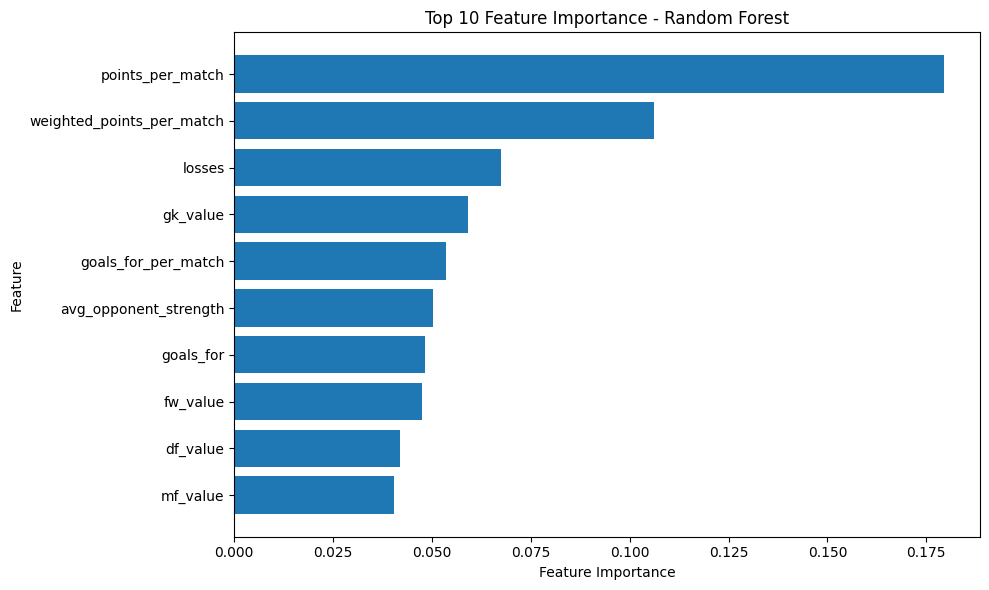

In [79]:
import matplotlib.pyplot as plt

# 상위 10개 feature importance 시각화
top_importance = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [80]:
# 결과 저장
results_df.to_csv("model_performance_results.csv", index=False)
importance_df.to_csv("feature_importance_results.csv", index=False)
ml_data.to_csv("worldcup_ml_dataset.csv", index=False)

print("저장 완료:")
print("worldcup_ml_dataset.csv")
print("model_performance_results.csv")
print("feature_importance_results.csv")

저장 완료:
worldcup_ml_dataset.csv
model_performance_results.csv
feature_importance_results.csv


In [81]:
from google.colab import files

files.download("worldcup_ml_dataset.csv")
files.download("model_performance_results.csv")
files.download("feature_importance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
display(results_df)

,model,MAE,RMSE,R2
1,Ridge Regression,0.996204,1.237708,0.159433
3,Random Forest,1.042885,1.284628,0.094495
0,Linear Regression,1.104897,1.345800,0.006205
4,Gradient Boosting,1.059435,1.357244,-0.010769
2,Decision Tree,1.269231,1.698416,-0.582792


In [83]:
# 2010, 2014, 2018 데이터로 학습하고 2022 월드컵을 예측하는 구조

train_data = ml_data[ml_data["world_cup_year"].isin([2010, 2014, 2018])].copy()
test_2022 = ml_data[ml_data["world_cup_year"] == 2022].copy()

X_train_2022 = train_data[feature_cols]
y_train_2022 = train_data[target_col]

X_test_2022 = test_2022[feature_cols]
y_test_2022 = test_2022[target_col]

print("Train data:", train_data.shape)
print("Test 2022 data:", test_2022.shape)

display(test_2022[["world_cup_year", "team", "stage_name", "stage_score"]].head())

Train data: (96, 26)
Test 2022 data: (31, 26)


,world_cup_year,team,stage_name,stage_score
128,2022,Qatar,Group stage,0
129,2022,Ecuador,Group stage,0
130,2022,Senegal,Round of 16,1
131,2022,Netherlands,Quarter-final,2
132,2022,England,Quarter-final,2


In [84]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models_2022 = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results_2022 = []

for name, model in models_2022.items():
    model.fit(X_train_2022, y_train_2022)
    pred = model.predict(X_test_2022)

    mae = mean_absolute_error(y_test_2022, pred)
    rmse = np.sqrt(mean_squared_error(y_test_2022, pred))
    r2 = r2_score(y_test_2022, pred)

    results_2022.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_2022_df = pd.DataFrame(results_2022).sort_values("RMSE")

display(results_2022_df)

,model,MAE,RMSE,R2
3,Random Forest,1.508602,1.695599,-0.682661
4,Gradient Boosting,1.477604,1.740522,-0.773002
1,Ridge Regression,1.550726,1.807486,-0.912054
0,Linear Regression,1.540618,1.823028,-0.945077
2,Decision Tree,1.612903,2.199707,-1.831912


In [85]:
# 가장 RMSE가 낮은 모델 선택
best_2022_model_name = results_2022_df.iloc[0]["model"]
best_2022_model = models_2022[best_2022_model_name]

# 2022 예측
pred_2022 = best_2022_model.predict(X_test_2022)

prediction_2022 = test_2022[[
    "world_cup_year",
    "team",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "avg_opponent_strength",
    "best11_market_value",
    "avg_best11_market_value"
]].copy()

prediction_2022["predicted_stage_score"] = pred_2022
prediction_2022["predicted_stage_score_rounded"] = np.round(pred_2022).clip(0, 5)

prediction_2022["predicted_rank"] = prediction_2022["predicted_stage_score"].rank(
    ascending=False,
    method="first"
).astype(int)

prediction_2022 = prediction_2022.sort_values("predicted_stage_score", ascending=False)

print("Best model for 2022 prediction:", best_2022_model_name)
display(prediction_2022)

Best model for 2022 prediction: Random Forest


,world_cup_year,team,stage_name,stage_score,points_per_match,weighted_points_per_match,avg_opponent_strength,best11_market_value,avg_best11_market_value,predicted_stage_score,predicted_stage_score_rounded,predicted_rank
148,2022,Belgium,Group stage,0,2.240000,3.072686,0.633401,407000000.0,3.700000e+07,3.580000,4.0,1
130,2022,Senegal,Round of 16,1,2.153846,2.805927,0.570201,235000000.0,2.136364e+07,3.333333,3.0,2
140,2022,France,Runner-up,4,2.142857,3.017930,0.637116,735000000.0,6.681818e+07,3.326667,3.0,3
144,2022,Spain,Round of 16,1,2.098039,3.009141,0.660661,633000000.0,5.754545e+07,3.096667,3.0,4
132,2022,England,Quarter-final,2,2.137255,2.957106,0.642430,805000000.0,7.318182e+07,3.033333,3.0,5
136,2022,Argentina,Champion,5,2.240000,3.184285,0.629135,440000000.0,4.000000e+07,3.030000,3.0,6
156,2022,Portugal,Quarter-final,2,2.081633,2.953694,0.667341,675000000.0,6.136364e+07,2.996667,3.0,7
146,2022,Germany,Group stage,0,1.897959,2.617005,0.668158,619000000.0,5.627273e+07,2.906667,3.0,8
152,2022,Brazil,Quarter-final,2,2.420000,3.436269,0.630888,725000000.0,6.590909e+07,2.856667,3.0,9
131,2022,Netherlands,Quarter-final,2,2.104167,3.026652,0.662996,433000000.0,3.936364e+07,2.770000,3.0,10


In [86]:
top10_2022 = prediction_2022.head(10).copy()

display(top10_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "best11_market_value"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score,points_per_match,weighted_points_per_match,best11_market_value
148,1,Belgium,3.580000,4.0,Group stage,0,2.240000,3.072686,407000000.0
130,2,Senegal,3.333333,3.0,Round of 16,1,2.153846,2.805927,235000000.0
140,3,France,3.326667,3.0,Runner-up,4,2.142857,3.017930,735000000.0
144,4,Spain,3.096667,3.0,Round of 16,1,2.098039,3.009141,633000000.0
132,5,England,3.033333,3.0,Quarter-final,2,2.137255,2.957106,805000000.0
136,6,Argentina,3.030000,3.0,Champion,5,2.240000,3.184285,440000000.0
156,7,Portugal,2.996667,3.0,Quarter-final,2,2.081633,2.953694,675000000.0
146,8,Germany,2.906667,3.0,Group stage,0,1.897959,2.617005,619000000.0
152,9,Brazil,2.856667,3.0,Quarter-final,2,2.420000,3.436269,725000000.0
131,10,Netherlands,2.770000,3.0,Quarter-final,2,2.104167,3.026652,433000000.0


In [87]:
results_2022_df.to_csv("model_performance_2022_prediction.csv", index=False)
prediction_2022.to_csv("country_prediction_2022.csv", index=False)
top10_2022.to_csv("top10_2022_prediction.csv", index=False)

print("저장 완료:")
print("model_performance_2022_prediction.csv")
print("country_prediction_2022.csv")
print("top10_2022_prediction.csv")

저장 완료:
model_performance_2022_prediction.csv
country_prediction_2022.csv
top10_2022_prediction.csv


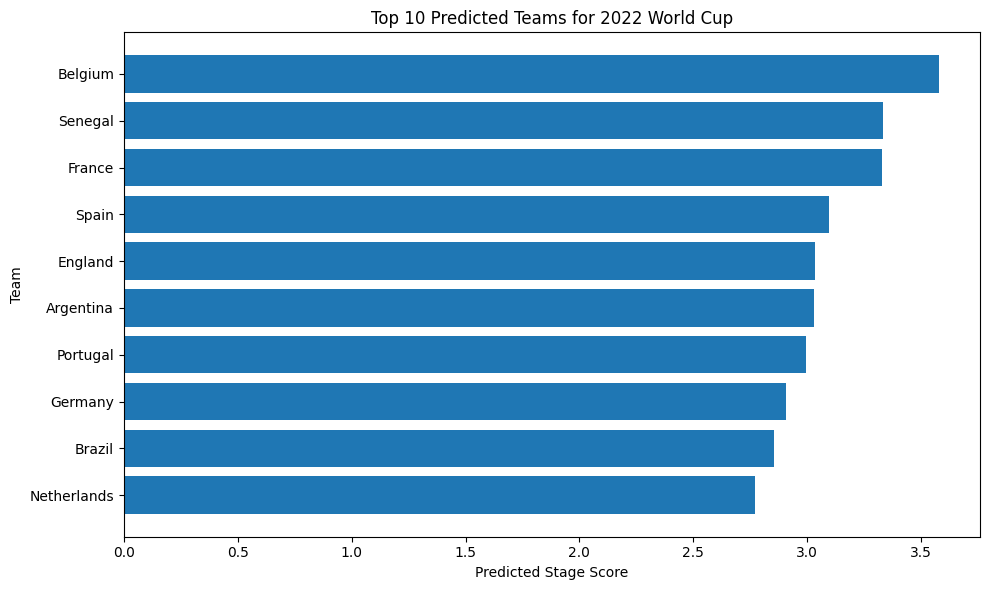

In [88]:
import matplotlib.pyplot as plt

plot_data = prediction_2022.head(10).sort_values("predicted_stage_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["team"], plot_data["predicted_stage_score"])
plt.xlabel("Predicted Stage Score")
plt.ylabel("Team")
plt.title("Top 10 Predicted Teams for 2022 World Cup")
plt.tight_layout()
plt.show()

In [89]:
# 2022 예측 결과 상위 10개 + 실제 성적 비교표

top10_2022 = prediction_2022.head(10).copy()

display(top10_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score",
    "points_per_match",
    "weighted_points_per_match",
    "avg_opponent_strength",
    "best11_market_value"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score,points_per_match,weighted_points_per_match,avg_opponent_strength,best11_market_value
148,1,Belgium,3.580000,4.0,Group stage,0,2.240000,3.072686,0.633401,407000000.0
130,2,Senegal,3.333333,3.0,Round of 16,1,2.153846,2.805927,0.570201,235000000.0
140,3,France,3.326667,3.0,Runner-up,4,2.142857,3.017930,0.637116,735000000.0
144,4,Spain,3.096667,3.0,Round of 16,1,2.098039,3.009141,0.660661,633000000.0
132,5,England,3.033333,3.0,Quarter-final,2,2.137255,2.957106,0.642430,805000000.0
136,6,Argentina,3.030000,3.0,Champion,5,2.240000,3.184285,0.629135,440000000.0
156,7,Portugal,2.996667,3.0,Quarter-final,2,2.081633,2.953694,0.667341,675000000.0
146,8,Germany,2.906667,3.0,Group stage,0,1.897959,2.617005,0.668158,619000000.0
152,9,Brazil,2.856667,3.0,Quarter-final,2,2.420000,3.436269,0.630888,725000000.0
131,10,Netherlands,2.770000,3.0,Quarter-final,2,2.104167,3.026652,0.662996,433000000.0


In [90]:
# 전체 2022 예측 결과 확인

display(prediction_2022[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "stage_name",
    "stage_score"
]])

,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,stage_name,stage_score
148,1,Belgium,3.580000,4.0,Group stage,0
130,2,Senegal,3.333333,3.0,Round of 16,1
140,3,France,3.326667,3.0,Runner-up,4
144,4,Spain,3.096667,3.0,Round of 16,1
132,5,England,3.033333,3.0,Quarter-final,2
136,6,Argentina,3.030000,3.0,Champion,5
156,7,Portugal,2.996667,3.0,Quarter-final,2
146,8,Germany,2.906667,3.0,Group stage,0
152,9,Brazil,2.856667,3.0,Quarter-final,2
131,10,Netherlands,2.770000,3.0,Quarter-final,2


In [91]:
# 최종 결과 저장

prediction_2022.to_csv("country_prediction_2022.csv", index=False)
top10_2022.to_csv("top10_2022_prediction.csv", index=False)
results_2022_df.to_csv("model_performance_2022_prediction.csv", index=False)
importance_df.to_csv("feature_importance_results.csv", index=False)

print("저장 완료")
print("country_prediction_2022.csv")
print("top10_2022_prediction.csv")
print("model_performance_2022_prediction.csv")
print("feature_importance_results.csv")

저장 완료
country_prediction_2022.csv
top10_2022_prediction.csv
model_performance_2022_prediction.csv
feature_importance_results.csv


In [92]:
from google.colab import files

files.download("country_prediction_2022.csv")
files.download("top10_2022_prediction.csv")
files.download("model_performance_2022_prediction.csv")
files.download("feature_importance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2026 World Cup Prediction

In [93]:
print("ml_data:", ml_data.shape)
print("feature_cols:", len(feature_cols))
print("matches:", matches.shape)
print("players:", players.shape)
print("valuations:", valuations.shape)

ml_data: (127, 26)
feature_cols: 21
matches: (51492, 8)
players: (47669, 26)
valuations: (640176, 6)


In [94]:
# 2026 World Cup Prediction
# FIFA World Cup 2026은 48개국 체제
# 여기서는 현재 확정/참가국 리스트를 기준으로 예측용 DataFrame을 만든다.
# 국가명은 기존 데이터셋의 표기와 최대한 맞춘다.

world_cup_teams_2026 = [
    "Canada", "Mexico", "United States",
    "Japan", "South Korea", "Iran", "Australia", "Qatar", "Saudi Arabia", "Uzbekistan",
    "Argentina", "Brazil", "Ecuador", "Uruguay", "Colombia", "Paraguay",
    "Morocco", "Tunisia", "Egypt", "Algeria", "Ghana", "Cape Verde", "South Africa",
    "Senegal", "Ivory Coast",
    "England", "France", "Spain", "Portugal", "Netherlands", "Germany", "Belgium",
    "Croatia", "Switzerland", "Austria", "Norway", "Scotland",
    "Czech Republic", "Italy", "Denmark", "Sweden", "Poland", "Turkey",
    "New Zealand",
    "Panama", "Haiti", "Curacao", "Jamaica", "Costa Rica"
]

wc_2026_df = pd.DataFrame({
    "world_cup_year": 2026,
    "team": world_cup_teams_2026
})

print("2026 teams:", wc_2026_df.shape)
display(wc_2026_df.head(20))

2026 teams: (49, 2)


,world_cup_year,team
0,2026,Canada
1,2026,Mexico
2,2026,United States
3,2026,Japan
4,2026,South Korea
5,2026,Iran
6,2026,Australia
7,2026,Qatar
8,2026,Saudi Arabia
9,2026,Uzbekistan


In [95]:
# 2026 참가국 국가명 표기 보정
# 기존 데이터셋의 국가명 표기와 맞추기 위한 처리

wc_2026_df["team"] = wc_2026_df["team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

matches["home_team"] = matches["home_team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

matches["away_team"] = matches["away_team"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

players["country_of_citizenship"] = players["country_of_citizenship"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

player_value_data["country_of_citizenship"] = player_value_data["country_of_citizenship"].replace({
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic"
})

print("국가명 표기 보정 완료")
display(wc_2026_df[wc_2026_df["team"].isin(["South Korea", "Iran", "Ivory Coast", "Czech Republic"])])

국가명 표기 보정 완료


,world_cup_year,team
4,2026,South Korea
5,2026,Iran
24,2026,Ivory Coast
37,2026,Czech Republic


In [96]:
# 2026 예측용 A매치 성적 기간
# 2022 월드컵 종료 다음날부터 데이터셋의 최신 날짜까지 사용

start_2026 = "2022-12-19"
end_2026 = matches["date"].max()

print("2026 feature period:", start_2026, "to", end_2026)

team_stats_2026_all = make_team_stats(
    matches_df=matches,
    start_date=start_2026,
    end_date=end_2026,
    wc_year=2026
)

team_stats_2026 = wc_2026_df.merge(
    team_stats_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 team stats:", team_stats_2026.shape)
display(team_stats_2026.head(20))

print("결측치 확인")
display(team_stats_2026.isnull().sum())

2026 feature period: 2022-12-19 to 2026-05-16 00:00:00
2026 team stats: (49, 17)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,weighted_points,goal_difference,win_rate,points_per_match,weighted_points_per_match,goals_for_per_match,goals_against_per_match
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,0.544180,89.893322,20.0,0.452381,1.714286,2.140317,1.428571,0.952381
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,0.543302,123.731945,28.0,0.500000,1.777778,2.291332,1.481481,0.962963
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,0.547965,111.469385,41.0,0.500000,1.673077,2.143642,1.942308,1.153846
3,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,0.498264,118.172312,94.0,0.756098,2.390244,2.882252,2.951220,0.658537
4,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,0.510181,100.383603,44.0,0.547619,1.928571,2.390086,1.928571,0.880952
5,2026,Iran,45.0,30.0,9.0,6.0,104.0,35.0,99.0,0.487213,114.726185,69.0,0.666667,2.200000,2.549471,2.311111,0.777778
6,2026,Australia,36.0,22.0,6.0,8.0,69.0,26.0,72.0,0.515945,87.464139,43.0,0.611111,2.000000,2.429559,1.916667,0.722222
7,2026,Qatar,51.0,20.0,12.0,19.0,75.0,74.0,72.0,0.501593,86.442076,1.0,0.392157,1.411765,1.694943,1.470588,1.450980
8,2026,Saudi Arabia,56.0,23.0,13.0,20.0,67.0,60.0,82.0,0.512797,96.963768,7.0,0.410714,1.464286,1.731496,1.196429,1.071429
9,2026,Uzbekistan,45.0,26.0,15.0,4.0,76.0,32.0,93.0,0.482761,107.627801,44.0,0.577778,2.066667,2.391729,1.688889,0.711111


결측치 확인


,0
world_cup_year,0
team,0
matches_played,1
wins,1
draws,1
losses,1
goals_for,1
goals_against,1
points,1
avg_opponent_strength,1


In [97]:
# 2026 시장가치 기준일
# 현재 valuations 데이터의 최신 날짜를 기준으로 사용

cutoff_2026 = valuations["date"].max()
print("2026 market value cutoff:", cutoff_2026)

latest_values_2026 = get_latest_values_before_cutoff(
    player_value_data,
    cutoff_2026,
    2026
)

market_2026_all = calculate_best11_market_value(
    latest_values_2026,
    2026
)

market_2026 = wc_2026_df.merge(
    market_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 market values:", market_2026.shape)
display(market_2026.head(20))

print("결측치 확인")
display(market_2026.isnull().sum())

2026 market value cutoff: 2026-05-18 00:00:00
2026 market values: (49, 9)


,world_cup_year,team,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,167500000.0,1.522727e+07,11.0,3500000.0,67000000.0,33000000.0,64000000.0
1,2026,Mexico,129500000.0,1.177273e+07,11.0,6500000.0,36000000.0,40000000.0,47000000.0
2,2026,United States,283500000.0,2.577273e+07,11.0,3500000.0,90000000.0,85000000.0,105000000.0
3,2026,Japan,190000000.0,1.727273e+07,11.0,20000000.0,46000000.0,49000000.0,75000000.0
4,2026,South Korea,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026,Iran,24400000.0,2.218182e+06,11.0,1500000.0,4000000.0,4400000.0,14500000.0
6,2026,Australia,49800000.0,4.527273e+06,11.0,2000000.0,25800000.0,10000000.0,12000000.0
7,2026,Qatar,16550000.0,1.504545e+06,11.0,700000.0,1850000.0,1700000.0,12300000.0
8,2026,Saudi Arabia,24500000.0,2.227273e+06,11.0,700000.0,10000000.0,7300000.0,6500000.0
9,2026,Uzbekistan,61700000.0,5.609091e+06,11.0,1500000.0,39000000.0,5200000.0,16000000.0


결측치 확인


,0
world_cup_year,0
team,0
best11_market_value,1
avg_best11_market_value,1
num_best11_players,1
gk_value,1
df_value,1
mf_value,1
fw_value,1


In [98]:
# 2026 예측용 데이터 다시 만들기: 국가명 표기 통일 + feature 재계산

# 1. 국가명 표기 통일 함수
def normalize_country_name(name):
    mapping = {
        "Korea Republic": "South Korea",
        "Republic of Korea": "South Korea",
        "Korea, South": "South Korea",
        "IR Iran": "Iran",
        "Iran, Islamic Republic of": "Iran",
        "United States of America": "United States",
        "USA": "United States",
        "US": "United States",
        "Cote d'Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Czechia": "Czech Republic",
        "Türkiye": "Turkey"
    }
    return mapping.get(name, name)

# 2. 원본 데이터 쪽 국가명 통일
matches["home_team"] = matches["home_team"].apply(normalize_country_name)
matches["away_team"] = matches["away_team"].apply(normalize_country_name)
players["country_of_citizenship"] = players["country_of_citizenship"].apply(normalize_country_name)

# player_value_data도 다시 생성하는 게 안전함
player_value_data = valuations.merge(
    players[["player_id", "name", "country_of_citizenship", "position", "sub_position"]],
    on="player_id",
    how="left"
)

player_value_data["position_group"] = player_value_data["position"].apply(position_group)
player_value_data["country_of_citizenship"] = player_value_data["country_of_citizenship"].apply(normalize_country_name)

# 3. 2026 참가국 리스트도 통일
world_cup_teams_2026 = [
    "Canada", "Mexico", "United States",
    "Japan", "South Korea", "Iran", "Australia", "Qatar", "Saudi Arabia", "Uzbekistan",
    "Argentina", "Brazil", "Ecuador", "Uruguay", "Colombia", "Paraguay",
    "Morocco", "Tunisia", "Egypt", "Algeria", "Ghana", "Cape Verde", "South Africa",
    "Senegal", "Ivory Coast",
    "England", "France", "Spain", "Portugal", "Netherlands", "Germany", "Belgium",
    "Croatia", "Switzerland", "Austria", "Norway", "Scotland",
    "Czech Republic", "Italy", "Denmark", "Sweden", "Poland", "Turkey",
    "New Zealand",
    "Panama", "Haiti", "Curacao", "Jamaica", "Costa Rica"
]

world_cup_teams_2026 = [normalize_country_name(x) for x in world_cup_teams_2026]

wc_2026_df = pd.DataFrame({
    "world_cup_year": 2026,
    "team": world_cup_teams_2026
})

print("2026 teams:", wc_2026_df.shape)
display(wc_2026_df.head(20))

# 4. 한국이 실제로 데이터에 있는지 확인
print("matches에서 Korea 포함 팀명:")
print(sorted(set(
    matches.loc[
        matches["home_team"].str.contains("Korea", case=False, na=False) |
        matches["away_team"].str.contains("Korea", case=False, na=False),
        ["home_team", "away_team"]
    ].values.ravel()
)))

print("players에서 Korea 포함 국적:")
print(sorted(players.loc[
    players["country_of_citizenship"].str.contains("Korea", case=False, na=False),
    "country_of_citizenship"
].dropna().unique()))

# 5. 2026 A매치 성적 feature 재계산
start_2026 = "2022-12-19"
end_2026 = matches["date"].max()

print("2026 feature period:", start_2026, "to", end_2026)

team_stats_2026_all = make_team_stats(
    matches_df=matches,
    start_date=start_2026,
    end_date=end_2026,
    wc_year=2026
)

team_stats_2026 = wc_2026_df.merge(
    team_stats_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

# 6. 2026 시장가치 feature 재계산
cutoff_2026 = valuations["date"].max()
print("2026 market value cutoff:", cutoff_2026)

latest_values_2026 = get_latest_values_before_cutoff(
    player_value_data,
    cutoff_2026,
    2026
)

market_2026_all = calculate_best11_market_value(
    latest_values_2026,
    2026
)

# 7. 성적 + 시장가치 합치기
prediction_base_2026 = team_stats_2026.merge(
    market_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 prediction base:", prediction_base_2026.shape)

# 한국 행 확인
display(prediction_base_2026[prediction_base_2026["team"].str.contains("Korea", case=False, na=False)])

# 전체 결측치 확인
display(prediction_base_2026.isnull().sum())

# 모델에 넣을 수 있는 행만 사용
prediction_data_2026 = prediction_base_2026.dropna(subset=feature_cols).copy()

print("2026 prediction data after dropna:", prediction_data_2026.shape)
display(prediction_data_2026.head())

2026 teams: (49, 2)


,world_cup_year,team
0,2026,Canada
1,2026,Mexico
2,2026,United States
3,2026,Japan
4,2026,South Korea
5,2026,Iran
6,2026,Australia
7,2026,Qatar
8,2026,Saudi Arabia
9,2026,Uzbekistan


matches에서 Korea 포함 팀명:
['Afghanistan', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Czech Republic', 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guam', 'Guatemala', 'Guinea', 'Haiti', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Libya', 'Macao', 'Malaysia', 'Maldives', 'Mali', 'Malta', 'Mexico', 'Moldova', 'Mongolia', 'Morocco', 'Myanmar', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'North Macedonia', 'North Vietnam', 'North Yemen', 'Northern Ireland', 'Norway', 'Oman', 'Pak

,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
4,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,0.510181,...,2.390086,1.928571,0.880952,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000


,0
world_cup_year,0
team,0
matches_played,1
wins,1
draws,1
losses,1
goals_for,1
goals_against,1
points,1
avg_opponent_strength,1


2026 prediction data after dropna: (48, 24)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,0.544180,...,2.140317,1.428571,0.952381,167500000,1.522727e+07,11,3500000,67000000,33000000,64000000
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,0.543302,...,2.291332,1.481481,0.962963,129500000,1.177273e+07,11,6500000,36000000,40000000,47000000
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,0.547965,...,2.143642,1.942308,1.153846,283500000,2.577273e+07,11,3500000,90000000,85000000,105000000
3,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,0.498264,...,2.882252,2.951220,0.658537,190000000,1.727273e+07,11,20000000,46000000,49000000,75000000
4,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,0.510181,...,2.390086,1.928571,0.880952,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000


In [99]:
# 2026 예측용 feature 데이터 결합

prediction_base_2026 = team_stats_2026.merge(
    market_2026_all,
    on=["world_cup_year", "team"],
    how="left"
)

print("2026 prediction base before dropna:", prediction_base_2026.shape)
display(prediction_base_2026.head(20))

print("결측치 확인")
display(prediction_base_2026.isnull().sum())

# 모델에 넣을 수 있는 행만 사용
prediction_data_2026 = prediction_base_2026.dropna(subset=feature_cols).copy()

print("2026 prediction data after dropna:", prediction_data_2026.shape)
display(prediction_data_2026.head())

2026 prediction base before dropna: (49, 24)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,0.544180,...,2.140317,1.428571,0.952381,167500000,1.522727e+07,11,3500000,67000000,33000000,64000000
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,0.543302,...,2.291332,1.481481,0.962963,129500000,1.177273e+07,11,6500000,36000000,40000000,47000000
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,0.547965,...,2.143642,1.942308,1.153846,283500000,2.577273e+07,11,3500000,90000000,85000000,105000000
3,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,0.498264,...,2.882252,2.951220,0.658537,190000000,1.727273e+07,11,20000000,46000000,49000000,75000000
4,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,0.510181,...,2.390086,1.928571,0.880952,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000
5,2026,Iran,45.0,30.0,9.0,6.0,104.0,35.0,99.0,0.487213,...,2.549471,2.311111,0.777778,24400000,2.218182e+06,11,1500000,4000000,4400000,14500000
6,2026,Australia,36.0,22.0,6.0,8.0,69.0,26.0,72.0,0.515945,...,2.429559,1.916667,0.722222,49800000,4.527273e+06,11,2000000,25800000,10000000,12000000
7,2026,Qatar,51.0,20.0,12.0,19.0,75.0,74.0,72.0,0.501593,...,1.694943,1.470588,1.450980,16550000,1.504545e+06,11,700000,1850000,1700000,12300000
8,2026,Saudi Arabia,56.0,23.0,13.0,20.0,67.0,60.0,82.0,0.512797,...,1.731496,1.196429,1.071429,24500000,2.227273e+06,11,700000,10000000,7300000,6500000
9,2026,Uzbekistan,45.0,26.0,15.0,4.0,76.0,32.0,93.0,0.482761,...,2.391729,1.688889,0.711111,61700000,5.609091e+06,11,1500000,39000000,5200000,16000000


결측치 확인


,0
world_cup_year,0
team,0
matches_played,1
wins,1
draws,1
losses,1
goals_for,1
goals_against,1
points,1
avg_opponent_strength,1


2026 prediction data after dropna: (48, 24)


,world_cup_year,team,matches_played,wins,draws,losses,goals_for,goals_against,points,avg_opponent_strength,...,weighted_points_per_match,goals_for_per_match,goals_against_per_match,best11_market_value,avg_best11_market_value,num_best11_players,gk_value,df_value,mf_value,fw_value
0,2026,Canada,42.0,19.0,15.0,8.0,60.0,40.0,72.0,0.544180,...,2.140317,1.428571,0.952381,167500000,1.522727e+07,11,3500000,67000000,33000000,64000000
1,2026,Mexico,54.0,27.0,15.0,12.0,80.0,52.0,96.0,0.543302,...,2.291332,1.481481,0.962963,129500000,1.177273e+07,11,6500000,36000000,40000000,47000000
2,2026,United States,52.0,26.0,9.0,17.0,101.0,60.0,87.0,0.547965,...,2.143642,1.942308,1.153846,283500000,2.577273e+07,11,3500000,90000000,85000000,105000000
3,2026,Japan,41.0,31.0,5.0,5.0,121.0,27.0,98.0,0.498264,...,2.882252,2.951220,0.658537,190000000,1.727273e+07,11,20000000,46000000,49000000,75000000
4,2026,South Korea,42.0,23.0,12.0,7.0,81.0,37.0,81.0,0.510181,...,2.390086,1.928571,0.880952,116800000,1.061818e+07,11,1000000,33800000,42000000,40000000


In [100]:
# 2010~2022 전체 데이터로 학습하고 2026 예측
# 2026은 실제 결과가 없으므로 MAE/RMSE 평가는 하지 않는다.

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

X_train_all = ml_data[feature_cols]
y_train_all = ml_data[target_col]

X_2026 = prediction_data_2026[feature_cols]

# 2022 검증에서 가장 좋았던 Linear Regression 대신,
# 과적합을 조금 줄이기 위해 Ridge를 기본 예측 모델로 사용
final_model_2026 = Ridge(alpha=1.0)
final_model_2026.fit(X_train_all, y_train_all)

pred_2026 = final_model_2026.predict(X_2026)

prediction_2026 = prediction_data_2026[[
    "world_cup_year",
    "team",
    "matches_played",
    "points_per_match",
    "weighted_points_per_match",
    "avg_opponent_strength",
    "best11_market_value",
    "avg_best11_market_value"
]].copy()

prediction_2026["predicted_stage_score"] = pred_2026
prediction_2026["predicted_stage_score_rounded"] = np.round(pred_2026).clip(0, 5)

prediction_2026["predicted_rank"] = prediction_2026["predicted_stage_score"].rank(
    ascending=False,
    method="first"
).astype(int)

prediction_2026 = prediction_2026.sort_values("predicted_stage_score", ascending=False)

display(prediction_2026.head(20))

,world_cup_year,team,matches_played,points_per_match,weighted_points_per_match,avg_opponent_strength,best11_market_value,avg_best11_market_value,predicted_stage_score,predicted_stage_score_rounded,predicted_rank
26,2026,France,38.0,2.157895,2.675315,0.531521,950000000,8.636364e+07,3.331428,3.0,1
27,2026,Spain,39.0,2.435897,3.130725,0.538515,930000000,8.454545e+07,3.329683,3.0,2
28,2026,Portugal,38.0,2.236842,2.660180,0.490022,687000000,6.245455e+07,2.202681,2.0,3
16,2026,Morocco,48.0,2.437500,2.788635,0.456346,342500000,3.113636e+07,2.201437,2.0,4
23,2026,Senegal,43.0,2.441860,2.856608,0.463401,319000000,2.900000e+07,2.101524,2.0,5
10,2026,Argentina,37.0,2.513514,3.010459,0.479229,600000000,5.454545e+07,2.058960,2.0,6
25,2026,England,39.0,2.179487,2.566447,0.495272,883000000,8.027273e+07,2.044052,2.0,7
19,2026,Algeria,46.0,2.260870,2.615710,0.459268,206000000,1.872727e+07,2.019300,2.0,8
35,2026,Norway,32.0,1.968750,2.270219,0.492046,454000000,4.127273e+07,1.898529,2.0,9
11,2026,Brazil,35.0,1.571429,2.033295,0.578144,687000000,6.245455e+07,1.870225,2.0,10


,predicted_rank,team,predicted_stage_score,predicted_stage_score_rounded,points_per_match,weighted_points_per_match,best11_market_value
26,1,France,3.331428,3.0,2.157895,2.675315,950000000
27,2,Spain,3.329683,3.0,2.435897,3.130725,930000000
28,3,Portugal,2.202681,2.0,2.236842,2.660180,687000000
16,4,Morocco,2.201437,2.0,2.437500,2.788635,342500000
23,5,Senegal,2.101524,2.0,2.441860,2.856608,319000000
10,6,Argentina,2.058960,2.0,2.513514,3.010459,600000000
25,7,England,2.044052,2.0,2.179487,2.566447,883000000
19,8,Algeria,2.019300,2.0,2.260870,2.615710,206000000
35,9,Norway,1.898529,2.0,1.968750,2.270219,454000000
11,10,Brazil,1.870225,2.0,1.571429,2.033295,687000000


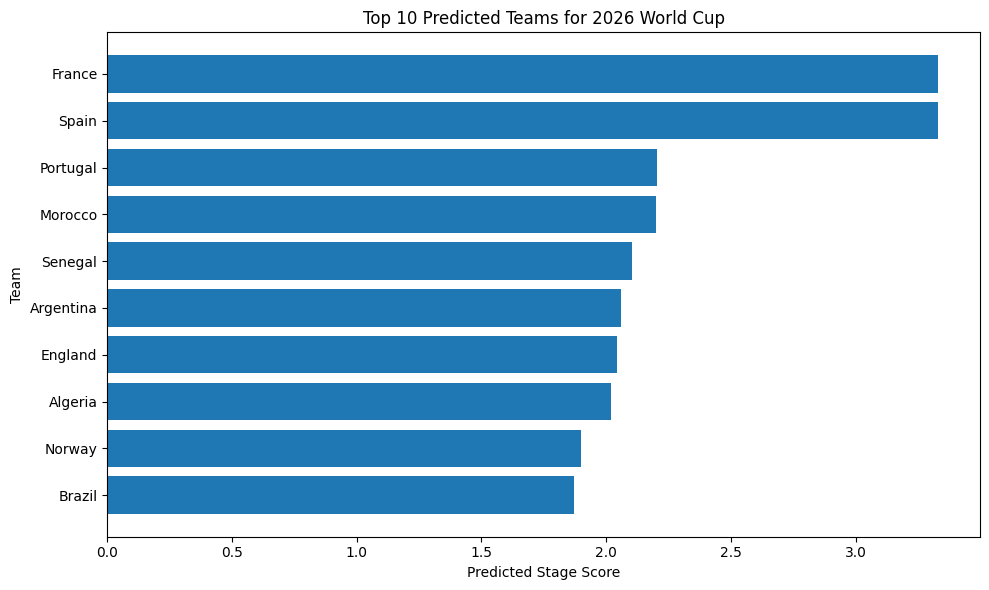

In [101]:
top10_2026 = prediction_2026.head(10).copy()

display(top10_2026[[
    "predicted_rank",
    "team",
    "predicted_stage_score",
    "predicted_stage_score_rounded",
    "points_per_match",
    "weighted_points_per_match",
    "best11_market_value"
]])

import matplotlib.pyplot as plt

plot_data = top10_2026.sort_values("predicted_stage_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["team"], plot_data["predicted_stage_score"])
plt.xlabel("Predicted Stage Score")
plt.ylabel("Team")
plt.title("Top 10 Predicted Teams for 2026 World Cup")
plt.tight_layout()
plt.show()

In [102]:
prediction_2026.to_csv("country_prediction_2026.csv", index=False)
top10_2026.to_csv("top10_2026_prediction.csv", index=False)

print("저장 완료:")
print("country_prediction_2026.csv")
print("top10_2026_prediction.csv")

저장 완료:
country_prediction_2026.csv
top10_2026_prediction.csv


In [103]:
from google.colab import files

files.download("country_prediction_2026.csv")
files.download("top10_2026_prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>